### **Observed Arcs**

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm

# Data path
DATA_PATH = "tintin_selected_roll.csv"

# Load cleaned dataset
df_selected = pd.read_csv(DATA_PATH)

df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51700 entries, 0 to 51699
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   StoryID           51700 non-null  object 
 1   RegionSimplified  51700 non-null  object 
 2   Country           51700 non-null  object 
 3   GenreSimplified   51700 non-null  object 
 4   PanelOrdinal      51700 non-null  float64
 5   Valence           51658 non-null  float64
 6   Arousal           51696 non-null  float64
 7   valence_roll_5    48799 non-null  float64
 8   arousal_roll_5    48816 non-null  float64
dtypes: float64(5), object(4)
memory usage: 3.6+ MB


#### **Arousal**

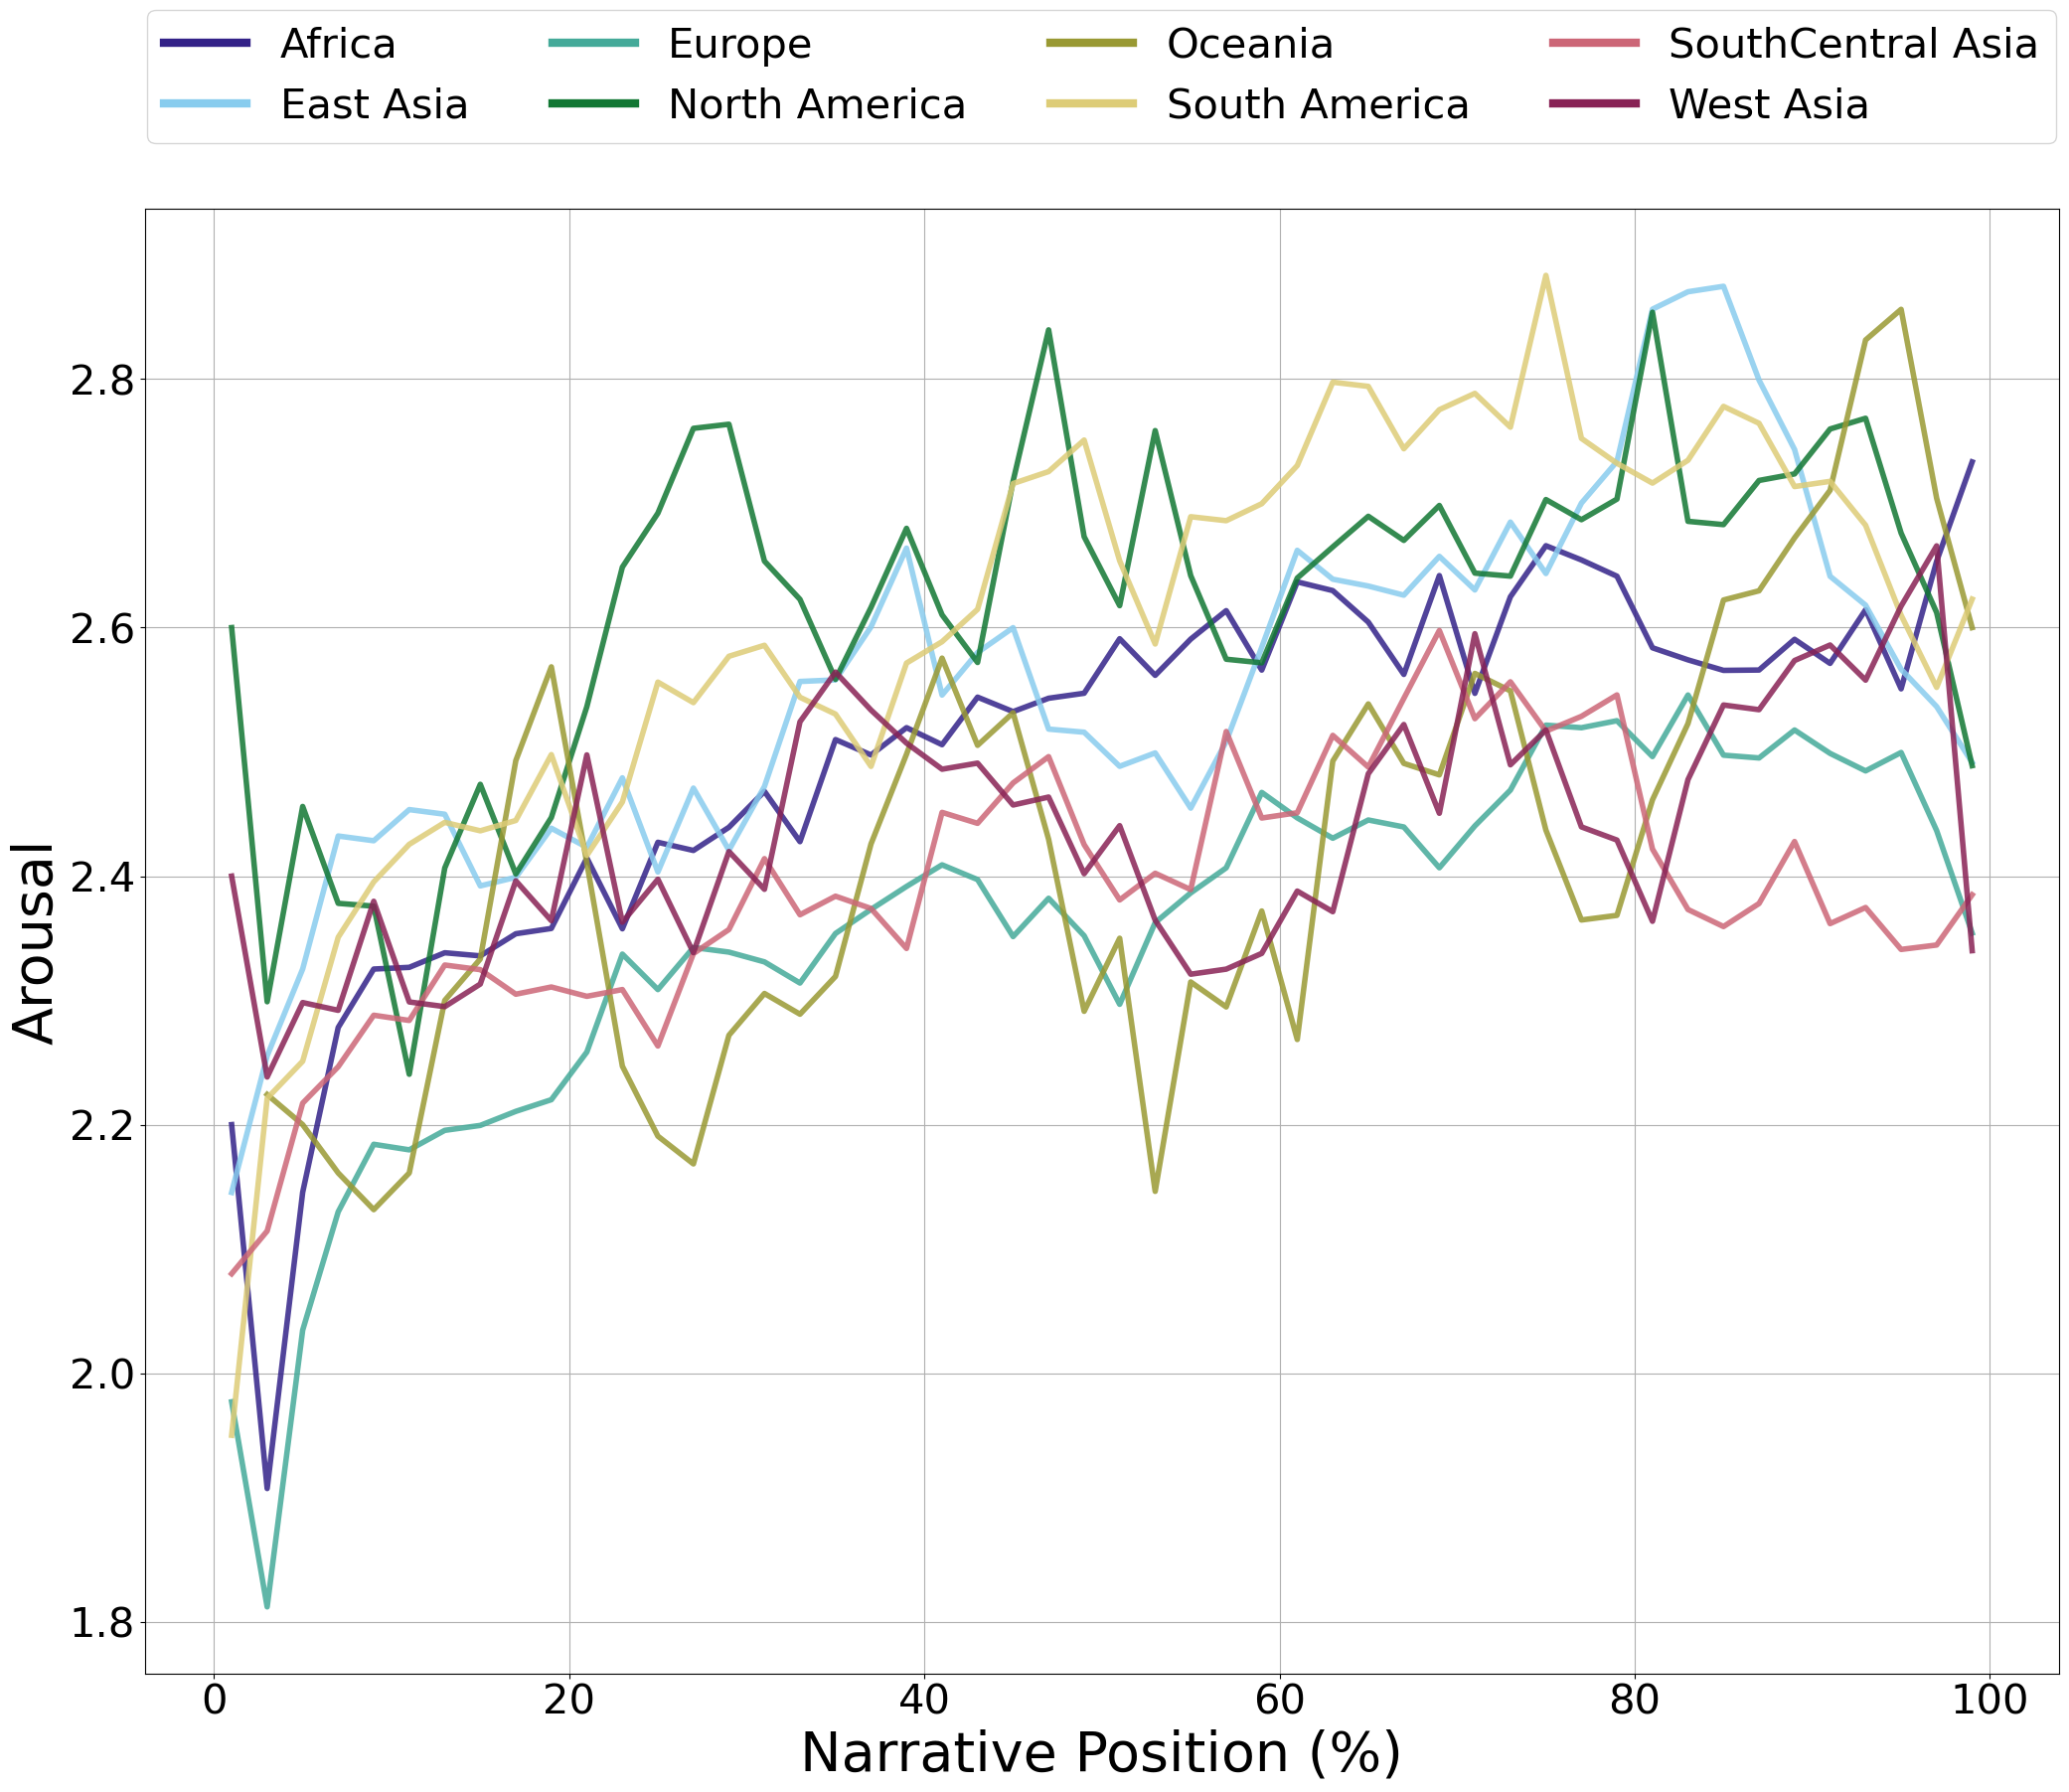

In [2]:
# Region colors & legend
region_names = [
    'Africa',  'East Asia','Europe', 'North America','Oceania', 'South America',"SouthCentral Asia",
    'West Asia',
]

color_palette = [
    "#332288",
    "#88CCEE",
    "#44AA99",
    "#117733",
    "#999933",
    "#DDCC77",
    "#CC6677",
    "#882255",
]

region_colors = dict(zip(region_names, color_palette))

legend_handles = [
    Line2D([0], [0], color=color, lw=6, label=region)
    for region, color in region_colors.items()
]

# Parameters
value_col = 'arousal_roll_5'
time_col = 'PanelOrdinal'
n_bins = 50

# Basic cleaning
# Remove rows without valid story-level SMA
df_selected = df_selected.dropna(subset=[value_col]).copy()

# Step 1: Temporal binning
bins = np.linspace(0, 1, n_bins + 1)

df_selected['progress_bin'] = pd.cut(
    df_selected[time_col],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Step 2: Story × Bin mean
story_bin = (
    df_selected
    .groupby(['RegionSimplified', 'StoryID', 'progress_bin'])[value_col]
    .mean()
    .reset_index()
)

# Step 3: Region × Bin mean
region_arc = (
    story_bin
    .groupby(['RegionSimplified', 'progress_bin'])[value_col]
    .mean()
    .reset_index(name='mean')
)

# Step 4: Bin centers for x-axis (%)
bin_centers = (bins[:-1] + bins[1:]) / 2 * 100

# Step 5: Plot
fig, ax = plt.subplots(figsize=(22, 18))

for region, color in region_colors.items():
    g = region_arc[region_arc['RegionSimplified'] == region].copy()
    g = g.dropna(subset=['progress_bin'])

    # Ensure integer indexing
    g['progress_bin'] = g['progress_bin'].astype(int)
    g['x'] = bin_centers[g['progress_bin']]

    ax.plot(
        g['x'],
        g['mean'],
        color=color,
        linewidth=4,
        alpha=0.85
    )

ax.set_xlabel('Narrative Position (%)', fontsize=40)
ax.set_ylabel('Arousal', fontsize=40)
ax.grid(True)
ax.tick_params(axis='both', labelsize=30)

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    fontsize=30,
    frameon=True
)

plt.tight_layout()
plt.show()

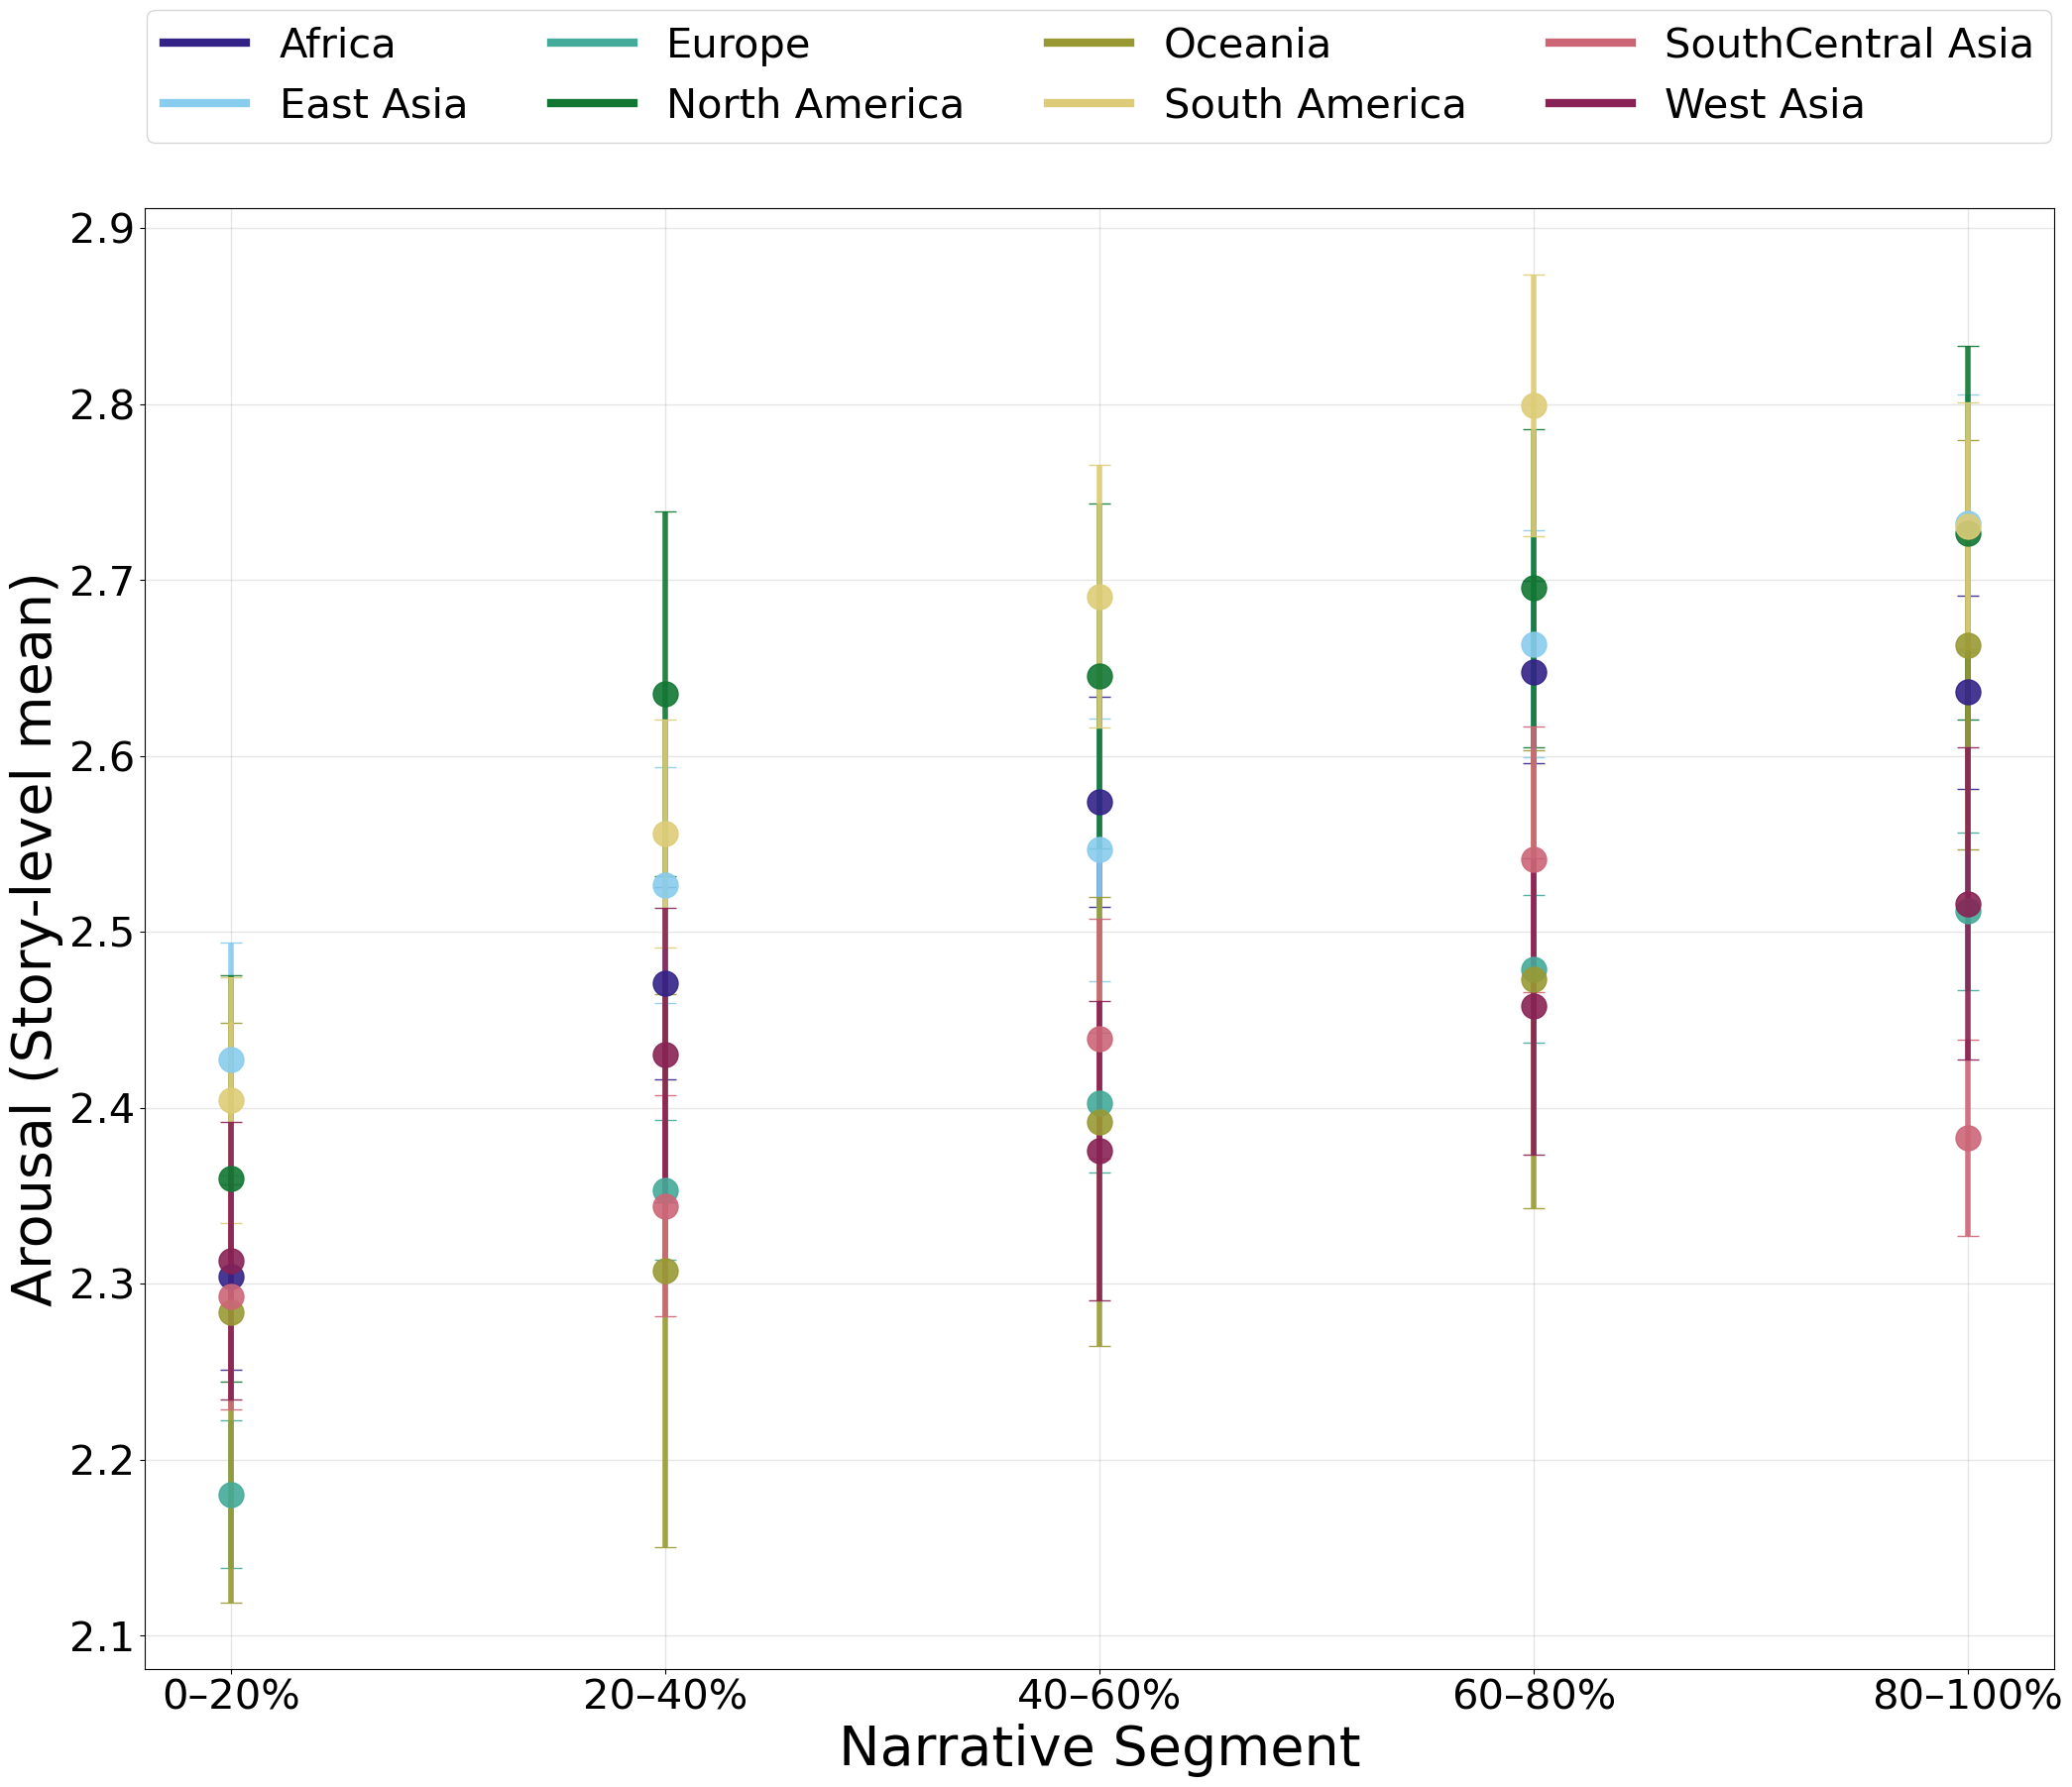

In [3]:
# Basic cleaning
df_selected = df_selected.dropna(subset=[value_col]).copy()

# Step 1: equal-width narrative segmentation
n_segments = 5

df_selected['Segment'] = pd.cut(
    df_selected[time_col],
    bins=n_segments,
    labels=False,
    include_lowest=True
)

# Step 2: story × segment mean
story_segment = (
    df_selected
    .groupby(['RegionSimplified', 'StoryID', 'Segment'])[value_col]
    .mean()
    .reset_index()
)

# Step 3: region × segment mean + SE
region_segment = (
    story_segment
    .groupby(['RegionSimplified', 'Segment'])[value_col]
    .agg(['mean', 'sem'])
    .reset_index()
    .rename(columns={'mean': 'MeanArousal', 'sem': 'SE'})
)

# Plot
fig, ax = plt.subplots(figsize=(22, 18))

for region, color in region_colors.items():

    g = region_segment[region_segment['RegionSimplified'] == region].copy()
    g = g.sort_values('Segment')

    ax.errorbar(
        g['Segment'],
        g['MeanArousal'],
        yerr=g['SE'],
        fmt='o',
        markersize=18,
        capsize=8,
        color=color,
        linewidth=4,
        alpha=0.9
    )

ax.set_xlabel('Narrative Segment', fontsize=40)
ax.set_ylabel('Arousal (Story-level mean)', fontsize=40)

ax.set_xticks(range(n_segments))
ax.set_xticklabels([
    '0–20%', '20–40%', '40–60%', '60–80%', '80–100%'
])

ax.set_axisbelow(True)
ax.grid(True, color='gray', alpha=0.2, linewidth=1)

ax.tick_params(axis='both', labelsize=30)

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    fontsize=30,
    frameon=True
)

plt.tight_layout()
plt.show()

In [4]:
region_segment_wide = (
    region_segment
    .assign(
        Mean_SE=lambda d: d['MeanArousal'].round(3).astype(str)
        + ' ± ' +
        d['SE'].round(3).astype(str)
    )
    .pivot(
        index='RegionSimplified',
        columns='Segment',
        values='Mean_SE'
    )
)

region_segment_wide.columns = [
    'Segment 1', 'Segment 2', 'Segment 3', 'Segment 4', 'Segment 5'
]

region_segment_wide.index.name = 'Region'

region_segment_wide

,Segment 1,Segment 2,Segment 3,Segment 4,Segment 5
Region,,,,,
Africa,2.304 ± 0.053,2.471 ± 0.055,2.574 ± 0.06,2.648 ± 0.052,2.636 ± 0.055
East Asia,2.428 ± 0.066,2.527 ± 0.067,2.547 ± 0.075,2.664 ± 0.064,2.732 ± 0.073
Europe,2.18 ± 0.042,2.353 ± 0.04,2.403 ± 0.04,2.479 ± 0.042,2.512 ± 0.045
North America,2.36 ± 0.116,2.635 ± 0.104,2.646 ± 0.098,2.695 ± 0.09,2.727 ± 0.106
Oceania,2.284 ± 0.165,2.307 ± 0.157,2.392 ± 0.128,2.473 ± 0.13,2.663 ± 0.116
South America,2.404 ± 0.07,2.556 ± 0.065,2.691 ± 0.075,2.799 ± 0.074,2.731 ± 0.07
SouthCentral Asia,2.293 ± 0.064,2.344 ± 0.063,2.439 ± 0.068,2.541 ± 0.075,2.383 ± 0.056
West Asia,2.313 ± 0.079,2.43 ± 0.084,2.375 ± 0.085,2.458 ± 0.084,2.516 ± 0.089


In [5]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pd.read_csv("tintin_selected_roll.csv")
df = df.dropna(subset=["arousal_roll_5"]).copy()

model = ols("arousal_roll_5 ~ C(RegionSimplified)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                           sum_sq       df           F         PR(>F)
C(RegionSimplified)    464.342808      7.0  118.750477  1.059328e-173
Residual             27264.424463  48808.0         NaN            NaN


In [6]:
anova_df = story_segment.copy()
anova_df = anova_df.rename(columns={value_col: 'Arousal'})

anova_df['RegionSimplified'] = anova_df['RegionSimplified'].astype('category')
anova_df['Segment'] = anova_df['Segment'].astype('category')

# Two-way ANOVA with interaction
model = ols(
    'Arousal ~ C(RegionSimplified) * C(Segment)',
    data=anova_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2) 
print(anova_table)

                                     sum_sq      df          F        PR(>F)
C(RegionSimplified)               33.094022     7.0  11.735217  7.588130e-15
C(Segment)                        43.507626     4.0  26.998835  4.223370e-22
C(RegionSimplified):C(Segment)     5.622643    28.0   0.498451  9.873287e-01
Residual                        1432.993553  3557.0        NaN           NaN


In [8]:
for seg in anova_df['Segment'].unique():
    subset = anova_df[anova_df['Segment'] == seg]
    
    tukey = pairwise_tukeyhsd(
        endog=subset['Arousal'],
        groups=subset['RegionSimplified'],
        alpha=0.05
    )
    
    print(f"Segment {seg}")
    print(tukey)

Segment 0
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
           Africa         East Asia   0.1238 0.8241 -0.1325  0.3801  False
           Africa            Europe  -0.1237 0.6119 -0.3312  0.0838  False
           Africa     North America   0.0559 0.9996 -0.2793  0.3911  False
           Africa           Oceania  -0.0203    1.0 -0.4834  0.4429  False
           Africa     South America   0.1005 0.9245 -0.1489  0.3499  False
           Africa SouthCentral Asia  -0.0113    1.0 -0.2866   0.264  False
           Africa         West Asia   0.0091    1.0 -0.2798  0.2979  False
        East Asia            Europe  -0.2475 0.0474 -0.4935 -0.0015   True
        East Asia     North America  -0.0679 0.9992 -0.4282  0.2924  False
        East Asia           Oceania  -0.1441 0.9852 -0.6257  0.3376  False
        East As

In [9]:
results = []

for seg in sorted(anova_df['Segment'].dropna().unique()):
    
    subset = anova_df[anova_df['Segment'] == seg]
    
    tukey = pairwise_tukeyhsd(
        endog=subset['Arousal'],
        groups=subset['RegionSimplified'],
        alpha=0.05
    )
    
    # Convert Tukey result to DataFrame
    tukey_df = pd.DataFrame(
        data=tukey.summary().data[1:],   # skip header
        columns=tukey.summary().data[0]
    )
    
    # Add segment info
    tukey_df['Segment'] = seg
    
    results.append(tukey_df)

# Combine all segments
tukey_all = pd.concat(results, ignore_index=True)

# Save to CSV
tukey_all.to_csv("tukey_segment_results.csv", index=False)

#Save to Excel
tukey_all.to_excel("tukey_segment_results.xlsx", index=False)

tukey_all.head()

,group1,group2,meandiff,p-adj,lower,upper,reject,Segment
0,Africa,East Asia,0.1238,0.8241,-0.1325,0.3801,False,0
1,Africa,Europe,-0.1237,0.6119,-0.3312,0.0838,False,0
2,Africa,North America,0.0559,0.9996,-0.2793,0.3911,False,0
3,Africa,Oceania,-0.0203,1.0000,-0.4834,0.4429,False,0
4,Africa,South America,0.1005,0.9245,-0.1489,0.3499,False,0


#### **Valence**

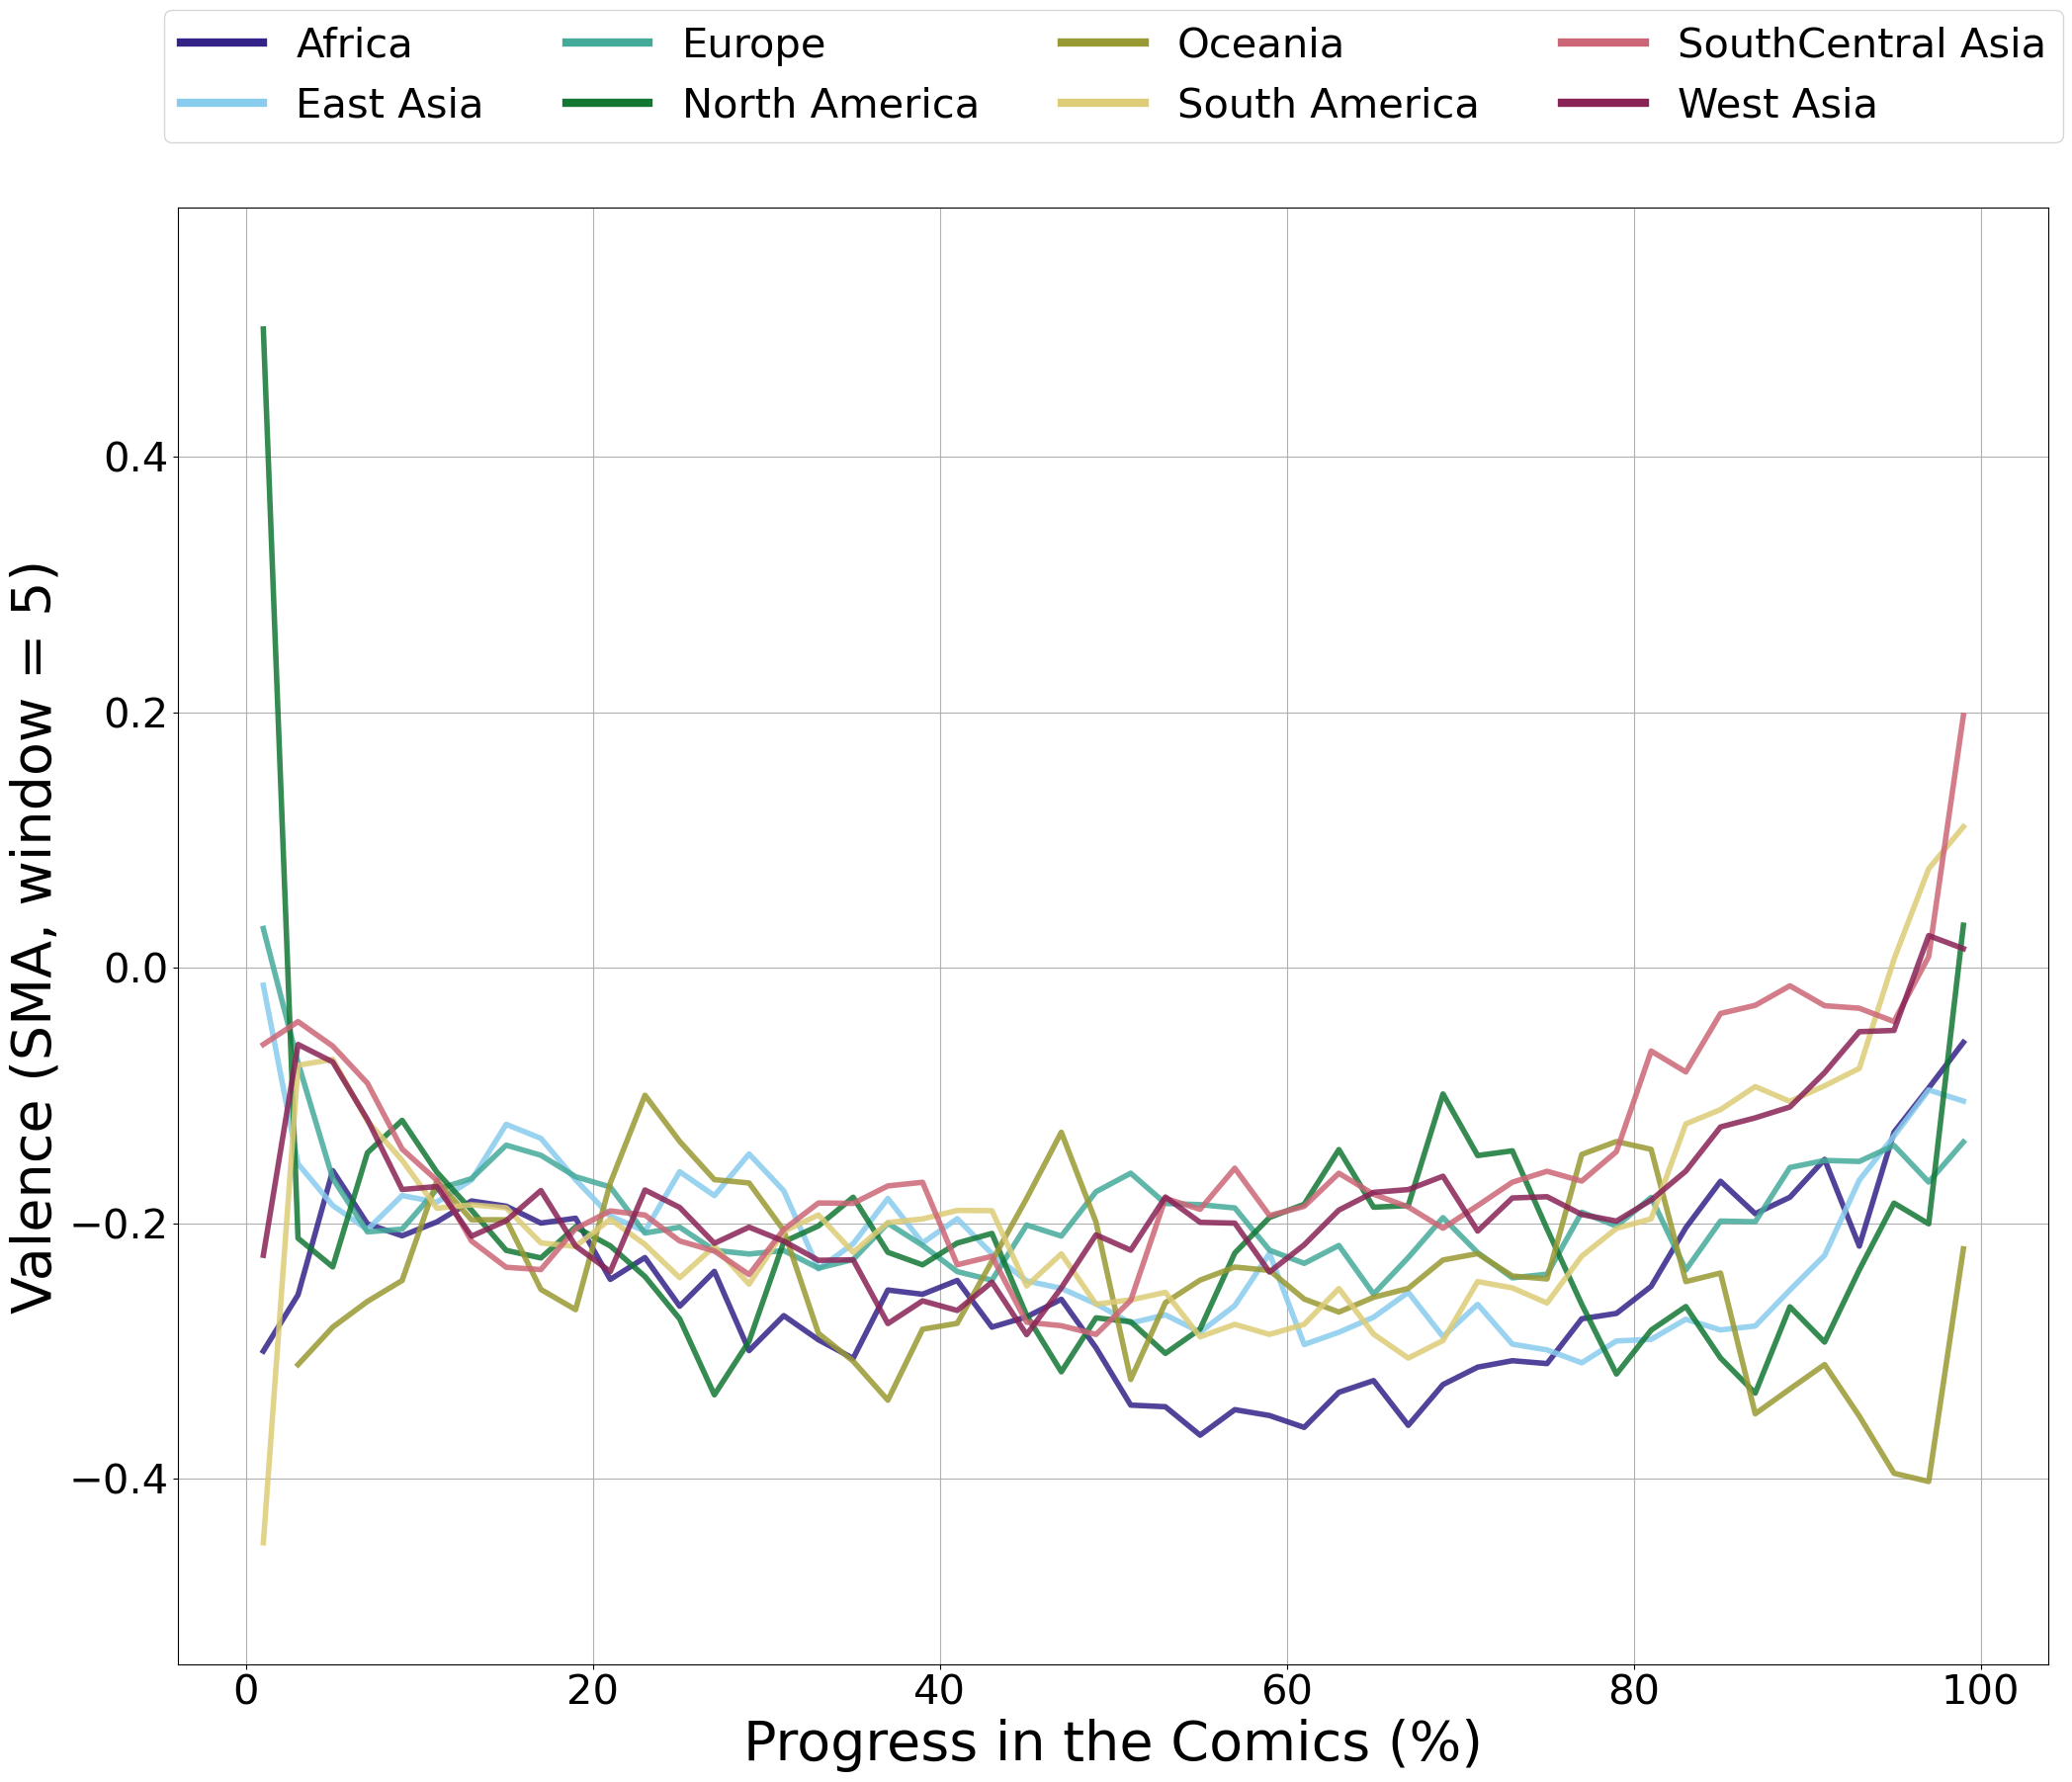

In [11]:
# Region colors & legend
region_names = [
    'Africa',  'East Asia','Europe', 'North America','Oceania', 'South America',"SouthCentral Asia",
    'West Asia',
]

color_palette = [
    "#332288",
    "#88CCEE",
    "#44AA99",
    "#117733",
    "#999933",
    "#DDCC77",
    "#CC6677",
    "#882255",
]


region_colors = dict(zip(region_names, color_palette))

legend_handles = [
    Line2D([0], [0], color=color, lw=6, label=region)
    for region, color in region_colors.items()
]

# Parameters
value_col = 'valence_roll_5'   
time_col = 'PanelOrdinal'    
n_bins = 50                  

# Remove rows without valid story-level SMA
df = df.dropna(subset=[value_col]).copy()


# Step 1: Temporal binning
bins = np.linspace(0, 1, n_bins + 1)

df['progress_bin'] = pd.cut(
    df[time_col],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Step 2: Story × Bin mean
story_bin = (
    df
    .groupby(['RegionSimplified', 'StoryID', 'progress_bin'])[value_col]
    .mean()
    .reset_index()
)


# Step 3: Region × Bin mean
region_arc = (
    story_bin
    .groupby(['RegionSimplified', 'progress_bin'])[value_col]
    .mean()
    .reset_index(name='mean')
)


# Step 4: Bin centers for x-axis (%)
bin_centers = (bins[:-1] + bins[1:]) / 2 * 100


# Step 5: Plot
fig, ax = plt.subplots(figsize=(22, 18))

for region, color in region_colors.items():

    g = region_arc[region_arc['RegionSimplified'] == region].copy()
    g = g.dropna(subset=['progress_bin'])

    # ensure integer indexing
    g['progress_bin'] = g['progress_bin'].astype(int)
    g['x'] = bin_centers[g['progress_bin']]

    ax.plot(
        g['x'],
        g['mean'],
        color=color,
        linewidth=4,
        alpha=0.85
    )

ymin = region_arc['mean'].min()
ymax = region_arc['mean'].max()
padding = 0.1 * (ymax - ymin)
ax.set_ylim(ymin - padding, ymax + padding)

ax.set_xlabel('Progress in the Comics (%)', fontsize=40)
ax.set_ylabel('Valence (SMA, window = 5)', fontsize=40)
ax.grid(True)
ax.tick_params(axis='both', labelsize=30)

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    fontsize=30,
    frameon=True
)

plt.tight_layout()
plt.show()

In [12]:
df = df.dropna(subset=[value_col]).copy()

# Step 1: quantile segmentation
n_segments = 5
df['Segment'] = pd.qcut(df[time_col], q=n_segments, labels=False)

# Step 2: story × segment mean
story_segment = (
    df
    .groupby(['RegionSimplified', 'StoryID', 'Segment'])[value_col]
    .mean()
    .reset_index()
)

# Step 3: region × segment mean + SE
region_segment = (
    story_segment
    .groupby(['RegionSimplified', 'Segment'])[value_col]
    .agg(['mean', 'sem'])
    .reset_index()
    .rename(columns={'mean': 'MeanValence', 'sem': 'SE'})
)

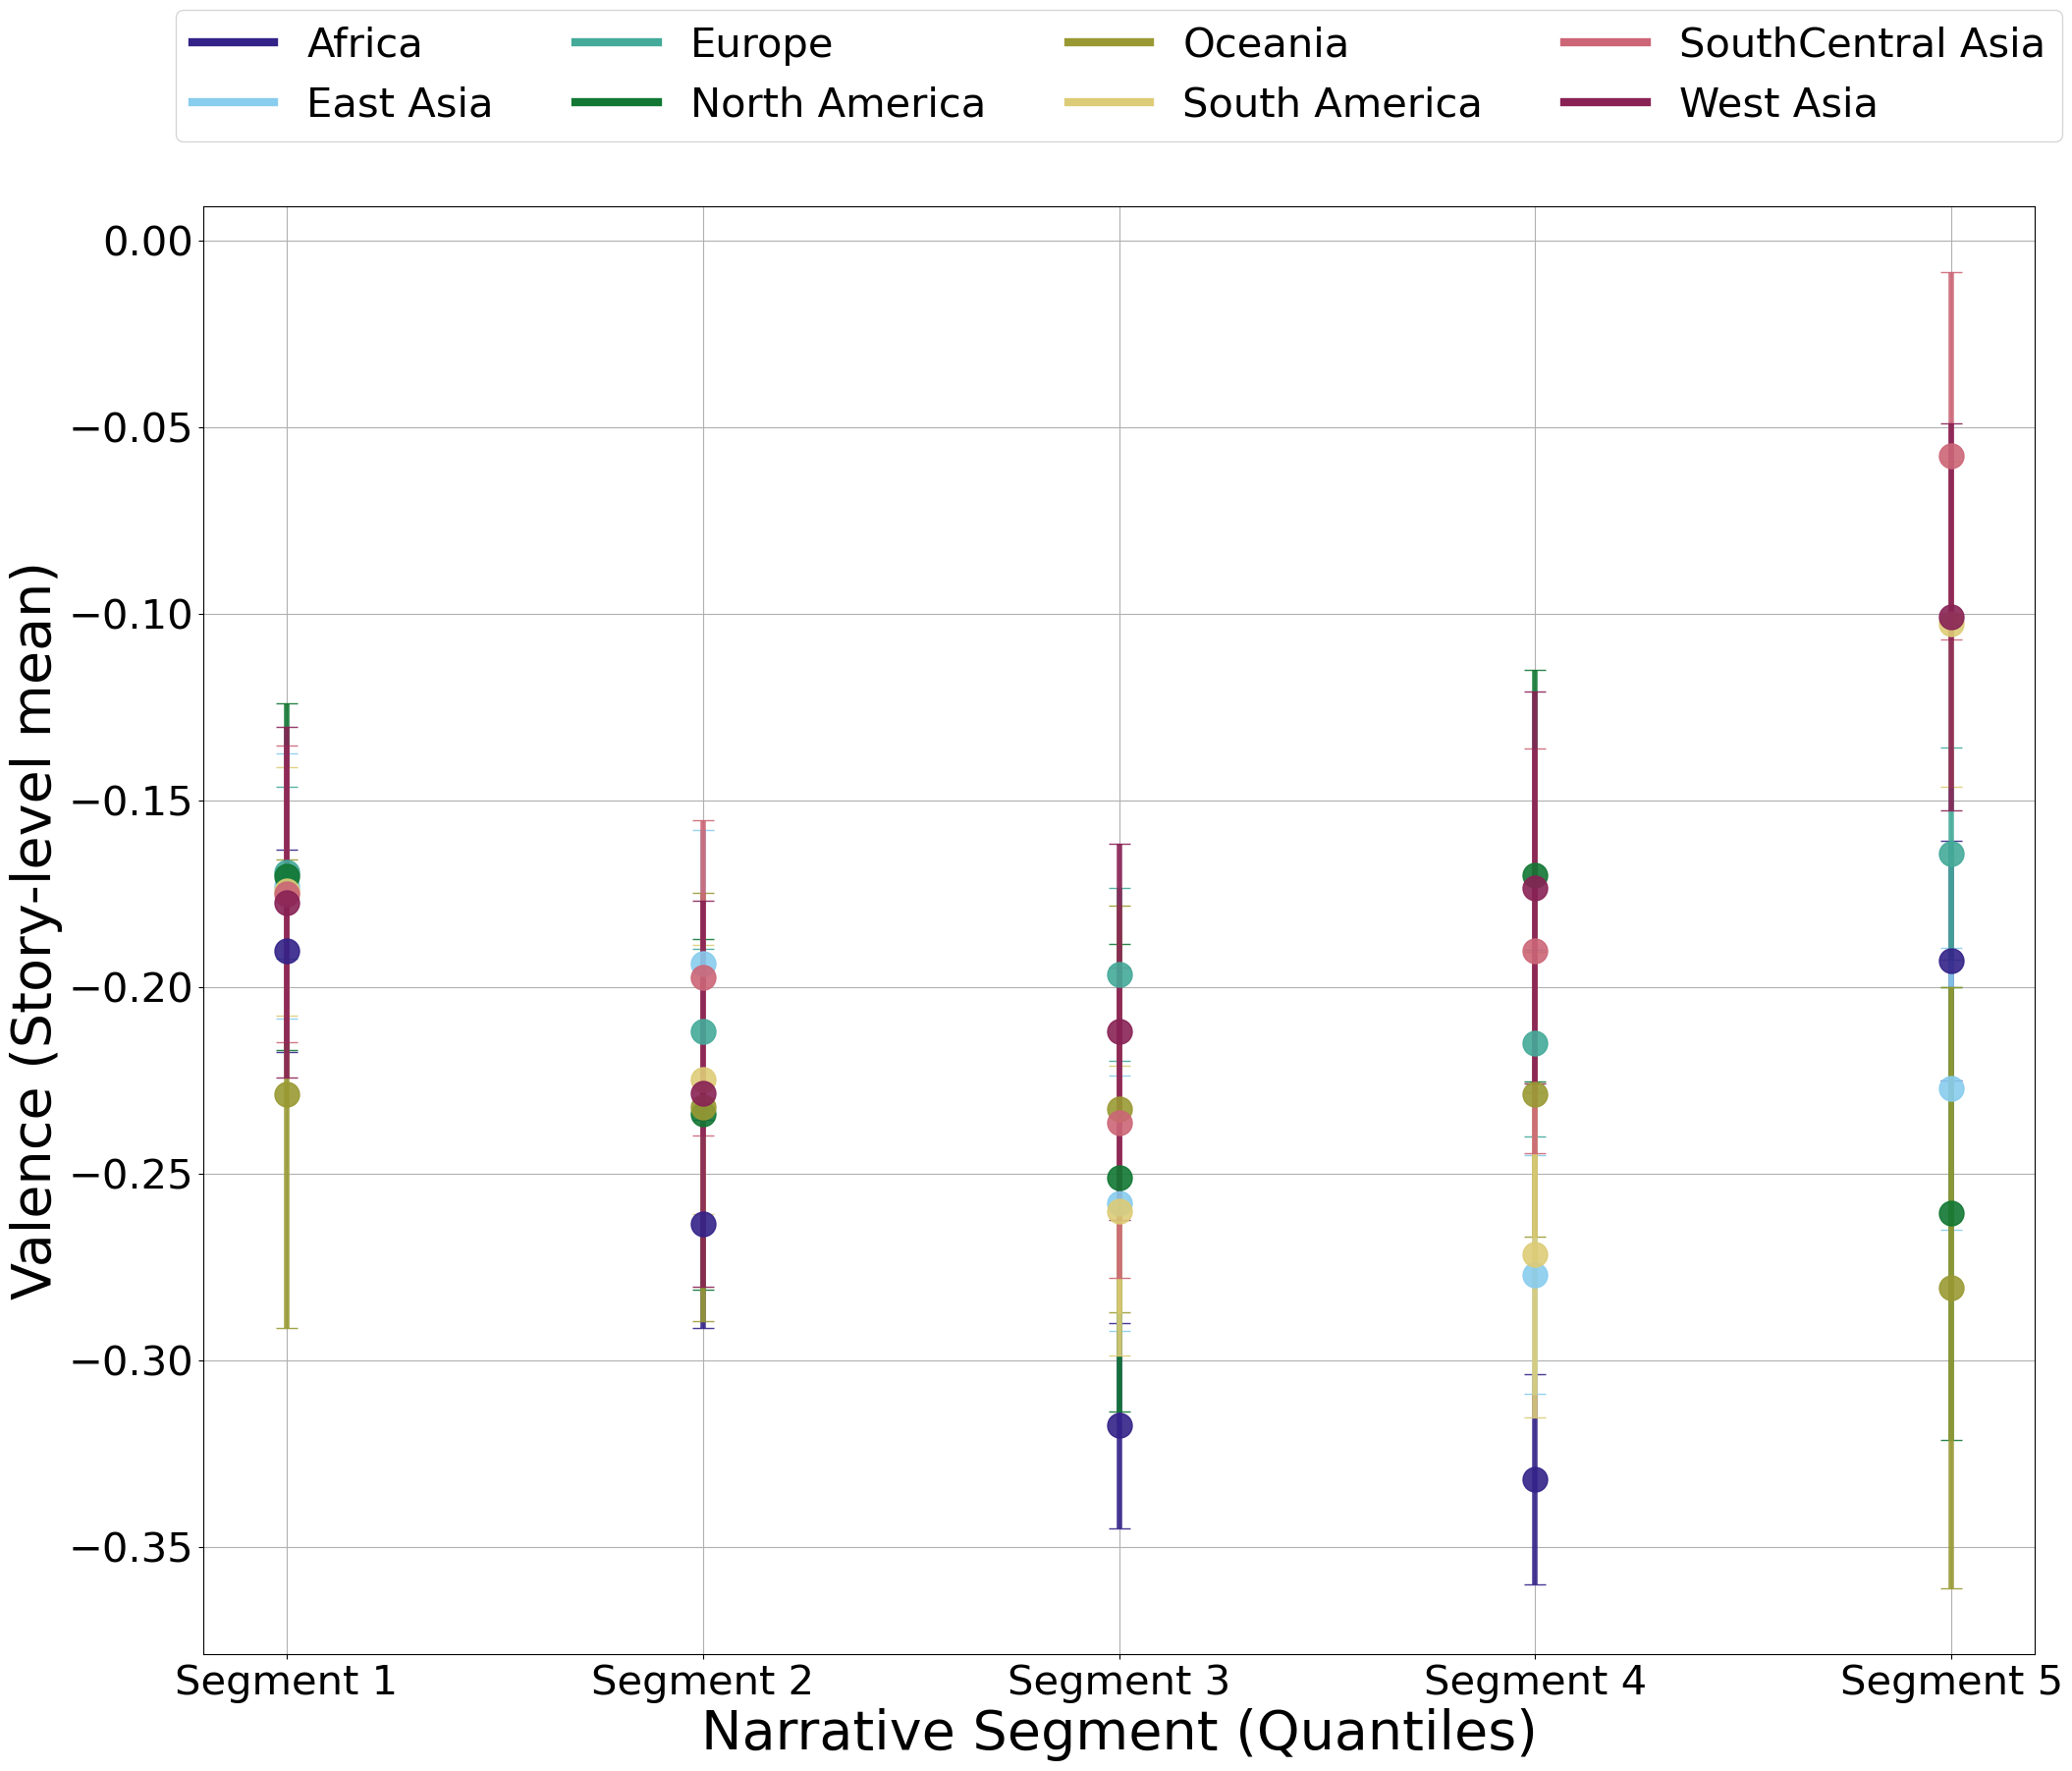

In [13]:
fig, ax = plt.subplots(figsize=(22, 18))

for region, color in region_colors.items():

    g = region_segment[region_segment['RegionSimplified'] == region].copy()

    ax.errorbar(
        g['Segment'],
        g['MeanValence'],
        yerr=g['SE'],
        fmt='o',
        markersize=18,
        capsize=8,
        color=color,
        linewidth=4,
        alpha=0.9
    )

ax.set_xlabel('Narrative Segment (Quantiles)', fontsize=40)
ax.set_ylabel('Valence (Story-level mean)', fontsize=40)
ax.set_xticks(range(n_segments))
ax.set_xticklabels([f'Segment {i+1}' for i in range(n_segments)])
ax.grid(True)
ax.tick_params(axis='both', labelsize=30)

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    fontsize=30,
    frameon=True
)

plt.tight_layout()
plt.show()

In [14]:
region_segment_wide = (
    region_segment
    .assign(
        Mean_SE=lambda d: d['MeanValence'].round(3).astype(str)
        + ' ± ' +
        d['SE'].round(3).astype(str)
    )
    .pivot(
        index='RegionSimplified',
        columns='Segment',
        values='Mean_SE'
    )
)

region_segment_wide

Segment,0,1,2,3,4
RegionSimplified,,,,,
Africa,-0.19 ± 0.027,-0.263 ± 0.028,-0.317 ± 0.028,-0.332 ± 0.028,-0.193 ± 0.032
East Asia,-0.173 ± 0.036,-0.194 ± 0.036,-0.258 ± 0.034,-0.277 ± 0.032,-0.227 ± 0.038
Europe,-0.169 ± 0.023,-0.212 ± 0.022,-0.197 ± 0.023,-0.215 ± 0.025,-0.164 ± 0.028
North America,-0.17 ± 0.046,-0.234 ± 0.047,-0.251 ± 0.063,-0.17 ± 0.055,-0.261 ± 0.061
Oceania,-0.229 ± 0.063,-0.232 ± 0.057,-0.233 ± 0.054,-0.229 ± 0.038,-0.28 ± 0.08
South America,-0.174 ± 0.033,-0.225 ± 0.036,-0.26 ± 0.039,-0.272 ± 0.044,-0.103 ± 0.044
SouthCentral Asia,-0.175 ± 0.04,-0.197 ± 0.042,-0.236 ± 0.042,-0.19 ± 0.054,-0.058 ± 0.049
West Asia,-0.177 ± 0.047,-0.228 ± 0.052,-0.212 ± 0.05,-0.173 ± 0.053,-0.101 ± 0.052


In [15]:
anova_df = story_segment.copy()
anova_df = anova_df.rename(columns={value_col: 'Valence'})

anova_df['RegionSimplified'] = anova_df['RegionSimplified'].astype('category')
anova_df['Segment'] = anova_df['Segment'].astype('category')

model = ols(
    'Valence ~ C(RegionSimplified) * C(Segment)',
    data=anova_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                    sum_sq      df         F        PR(>F)
C(RegionSimplified)               3.243059     7.0  3.660278  6.063956e-04
C(Segment)                        4.475105     4.0  8.838946  4.243731e-07
C(RegionSimplified):C(Segment)    3.391663    28.0  0.957000  5.295393e-01
Residual                        450.348433  3558.0       NaN           NaN


In [16]:
for seg in anova_df['Segment'].unique():
    subset = anova_df[anova_df['Segment'] == seg]
    
    tukey = pairwise_tukeyhsd(
        endog=subset['Valence'],
        groups=subset['RegionSimplified'],
        alpha=0.05
    )
    
    print(f"Segment {seg}")
    print(tukey)

Segment 0
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1            group2      meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------
           Africa         East Asia   0.0174 0.9999 -0.1169 0.1516  False
           Africa            Europe   0.0209  0.999 -0.0876 0.1295  False
           Africa     North America   0.0199    1.0 -0.1557 0.1955  False
           Africa           Oceania  -0.0383 0.9997 -0.2809 0.2043  False
           Africa     South America   0.0159    1.0 -0.1147 0.1466  False
           Africa SouthCentral Asia   0.0153    1.0  -0.129 0.1595  False
           Africa         West Asia    0.013    1.0 -0.1383 0.1642  False
        East Asia            Europe   0.0036    1.0 -0.1252 0.1323  False
        East Asia     North America   0.0025    1.0 -0.1862 0.1913  False
        East Asia           Oceania  -0.0557 0.9977  -0.308 0.1966  False
        East Asia     South 

In [18]:
results = []

for seg in sorted(anova_df['Segment'].dropna().unique()):
    
    subset = anova_df[anova_df['Segment'] == seg]
    
    tukey = pairwise_tukeyhsd(
        endog=subset['Valence'],
        groups=subset['RegionSimplified'],
        alpha=0.05
    )
    
    # Convert Tukey result to DataFrame
    tukey_df = pd.DataFrame(
        data=tukey.summary().data[1:],   # skip header
        columns=tukey.summary().data[0]
    )
    
    # Add segment info
    tukey_df['Segment'] = seg
    
    results.append(tukey_df)

# Combine all segments
tukey_all = pd.concat(results, ignore_index=True)

# Save to CSV
tukey_all.to_csv("tukey_segment_results_valence.csv", index=False)

#Save to Excel
tukey_all.to_excel("tukey_segment_results_valence.xlsx", index=False)

tukey_all.head()

,group1,group2,meandiff,p-adj,lower,upper,reject,Segment
0,Africa,East Asia,0.0174,0.9999,-0.1169,0.1516,False,0
1,Africa,Europe,0.0209,0.9990,-0.0876,0.1295,False,0
2,Africa,North America,0.0199,1.0000,-0.1557,0.1955,False,0
3,Africa,Oceania,-0.0383,0.9997,-0.2809,0.2043,False,0
4,Africa,South America,0.0159,1.0000,-0.1147,0.1466,False,0


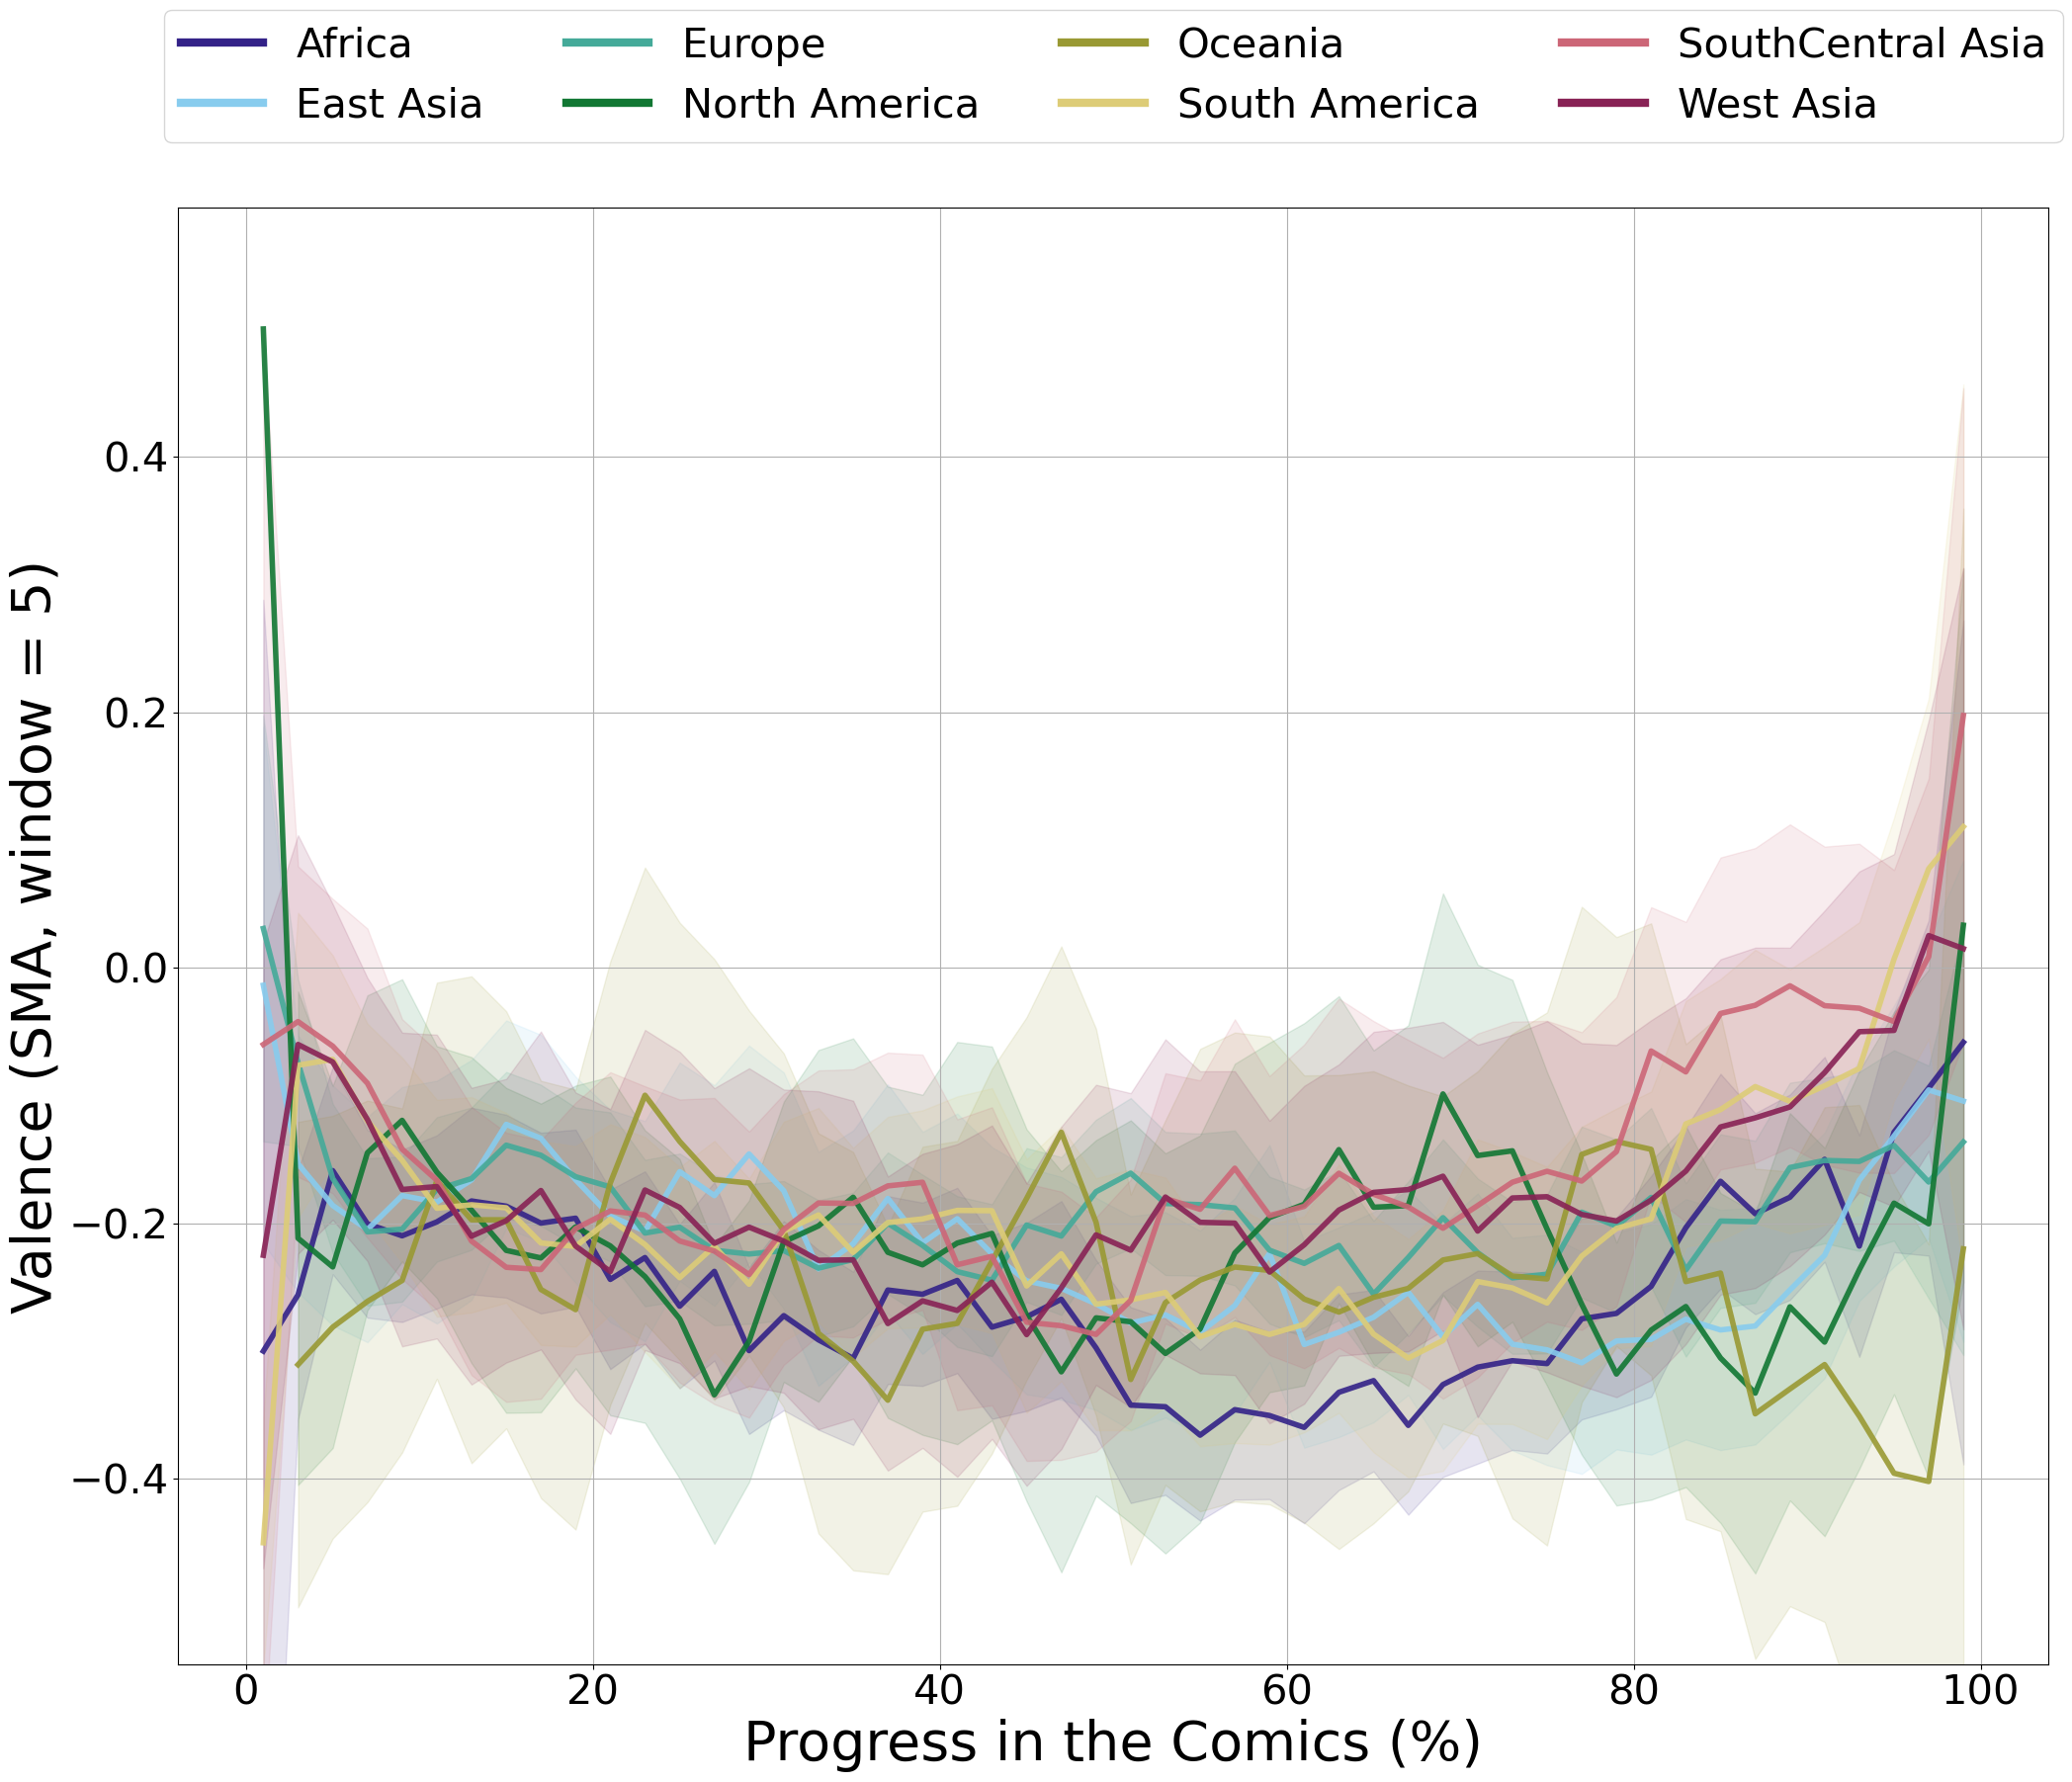

In [22]:
region_names = [
    'Africa',  'East Asia','Europe', 'North America','Oceania', 'South America',"SouthCentral Asia",
    'West Asia',
]

color_palette = [
    "#332288",
    "#88CCEE",
    "#44AA99",
    "#117733",
    "#999933",
    "#DDCC77",
    "#CC6677",
    "#882255",
]

region_colors = dict(zip(region_names, color_palette))

legend_handles = [
    Line2D([0], [0], color=color, lw=6, label=region)
    for region, color in region_colors.items()
]

# Parameters
value_col = 'valence_roll_5'   
time_col = 'PanelOrdinal'     
n_bins = 50                   

df = df.dropna(subset=[value_col]).copy()

# Step 1: Temporal binning
bins = np.linspace(0, 1, n_bins + 1)

df['progress_bin'] = pd.cut(
    df[time_col],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Step 2: Story × Bin mean
story_bin = (
    df
    .groupby(['RegionSimplified', 'StoryID', 'progress_bin'])[value_col]
    .mean()
    .reset_index()
)

# Step 3: Region × Bin mean + SE 
region_arc = (
    story_bin
    .groupby(['RegionSimplified', 'progress_bin'])[value_col]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

region_arc['SE'] = region_arc['std'] / np.sqrt(region_arc['count'])

# 95% CI multiplier
z95 = norm.ppf(0.975)
region_arc['CI'] = z95 * region_arc['SE']

# Step 4: Bin centers for x-axis (%)
bin_centers = (bins[:-1] + bins[1:]) / 2 * 100

# Step 5: Plot
fig, ax = plt.subplots(figsize=(22, 18))

for region, color in region_colors.items():

    g = region_arc[region_arc['RegionSimplified'] == region].copy()
    g = g.dropna(subset=['progress_bin'])

    g['progress_bin'] = g['progress_bin'].astype(int)
    g['x'] = bin_centers[g['progress_bin']]

    # Mean arc
    ax.plot(
        g['x'],
        g['mean'],
        color=color,
        linewidth=4,
        alpha=0.9
    )

    # 95% CI band
    ax.fill_between(
        g['x'],
        g['mean'] - g['CI'],
        g['mean'] + g['CI'],
        color=color,
        alpha=0.12
    )

ymin = region_arc['mean'].min()
ymax = region_arc['mean'].max()
padding = 0.1 * (ymax - ymin)
ax.set_ylim(ymin - padding, ymax + padding)

ax.set_xlabel('Progress in the Comics (%)', fontsize=40)
ax.set_ylabel('Valence (SMA, window = 5)', fontsize=40)
ax.grid(True)
ax.tick_params(axis='both', labelsize=30)

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    fontsize=30,
    frameon=True
)

plt.tight_layout()
plt.show()

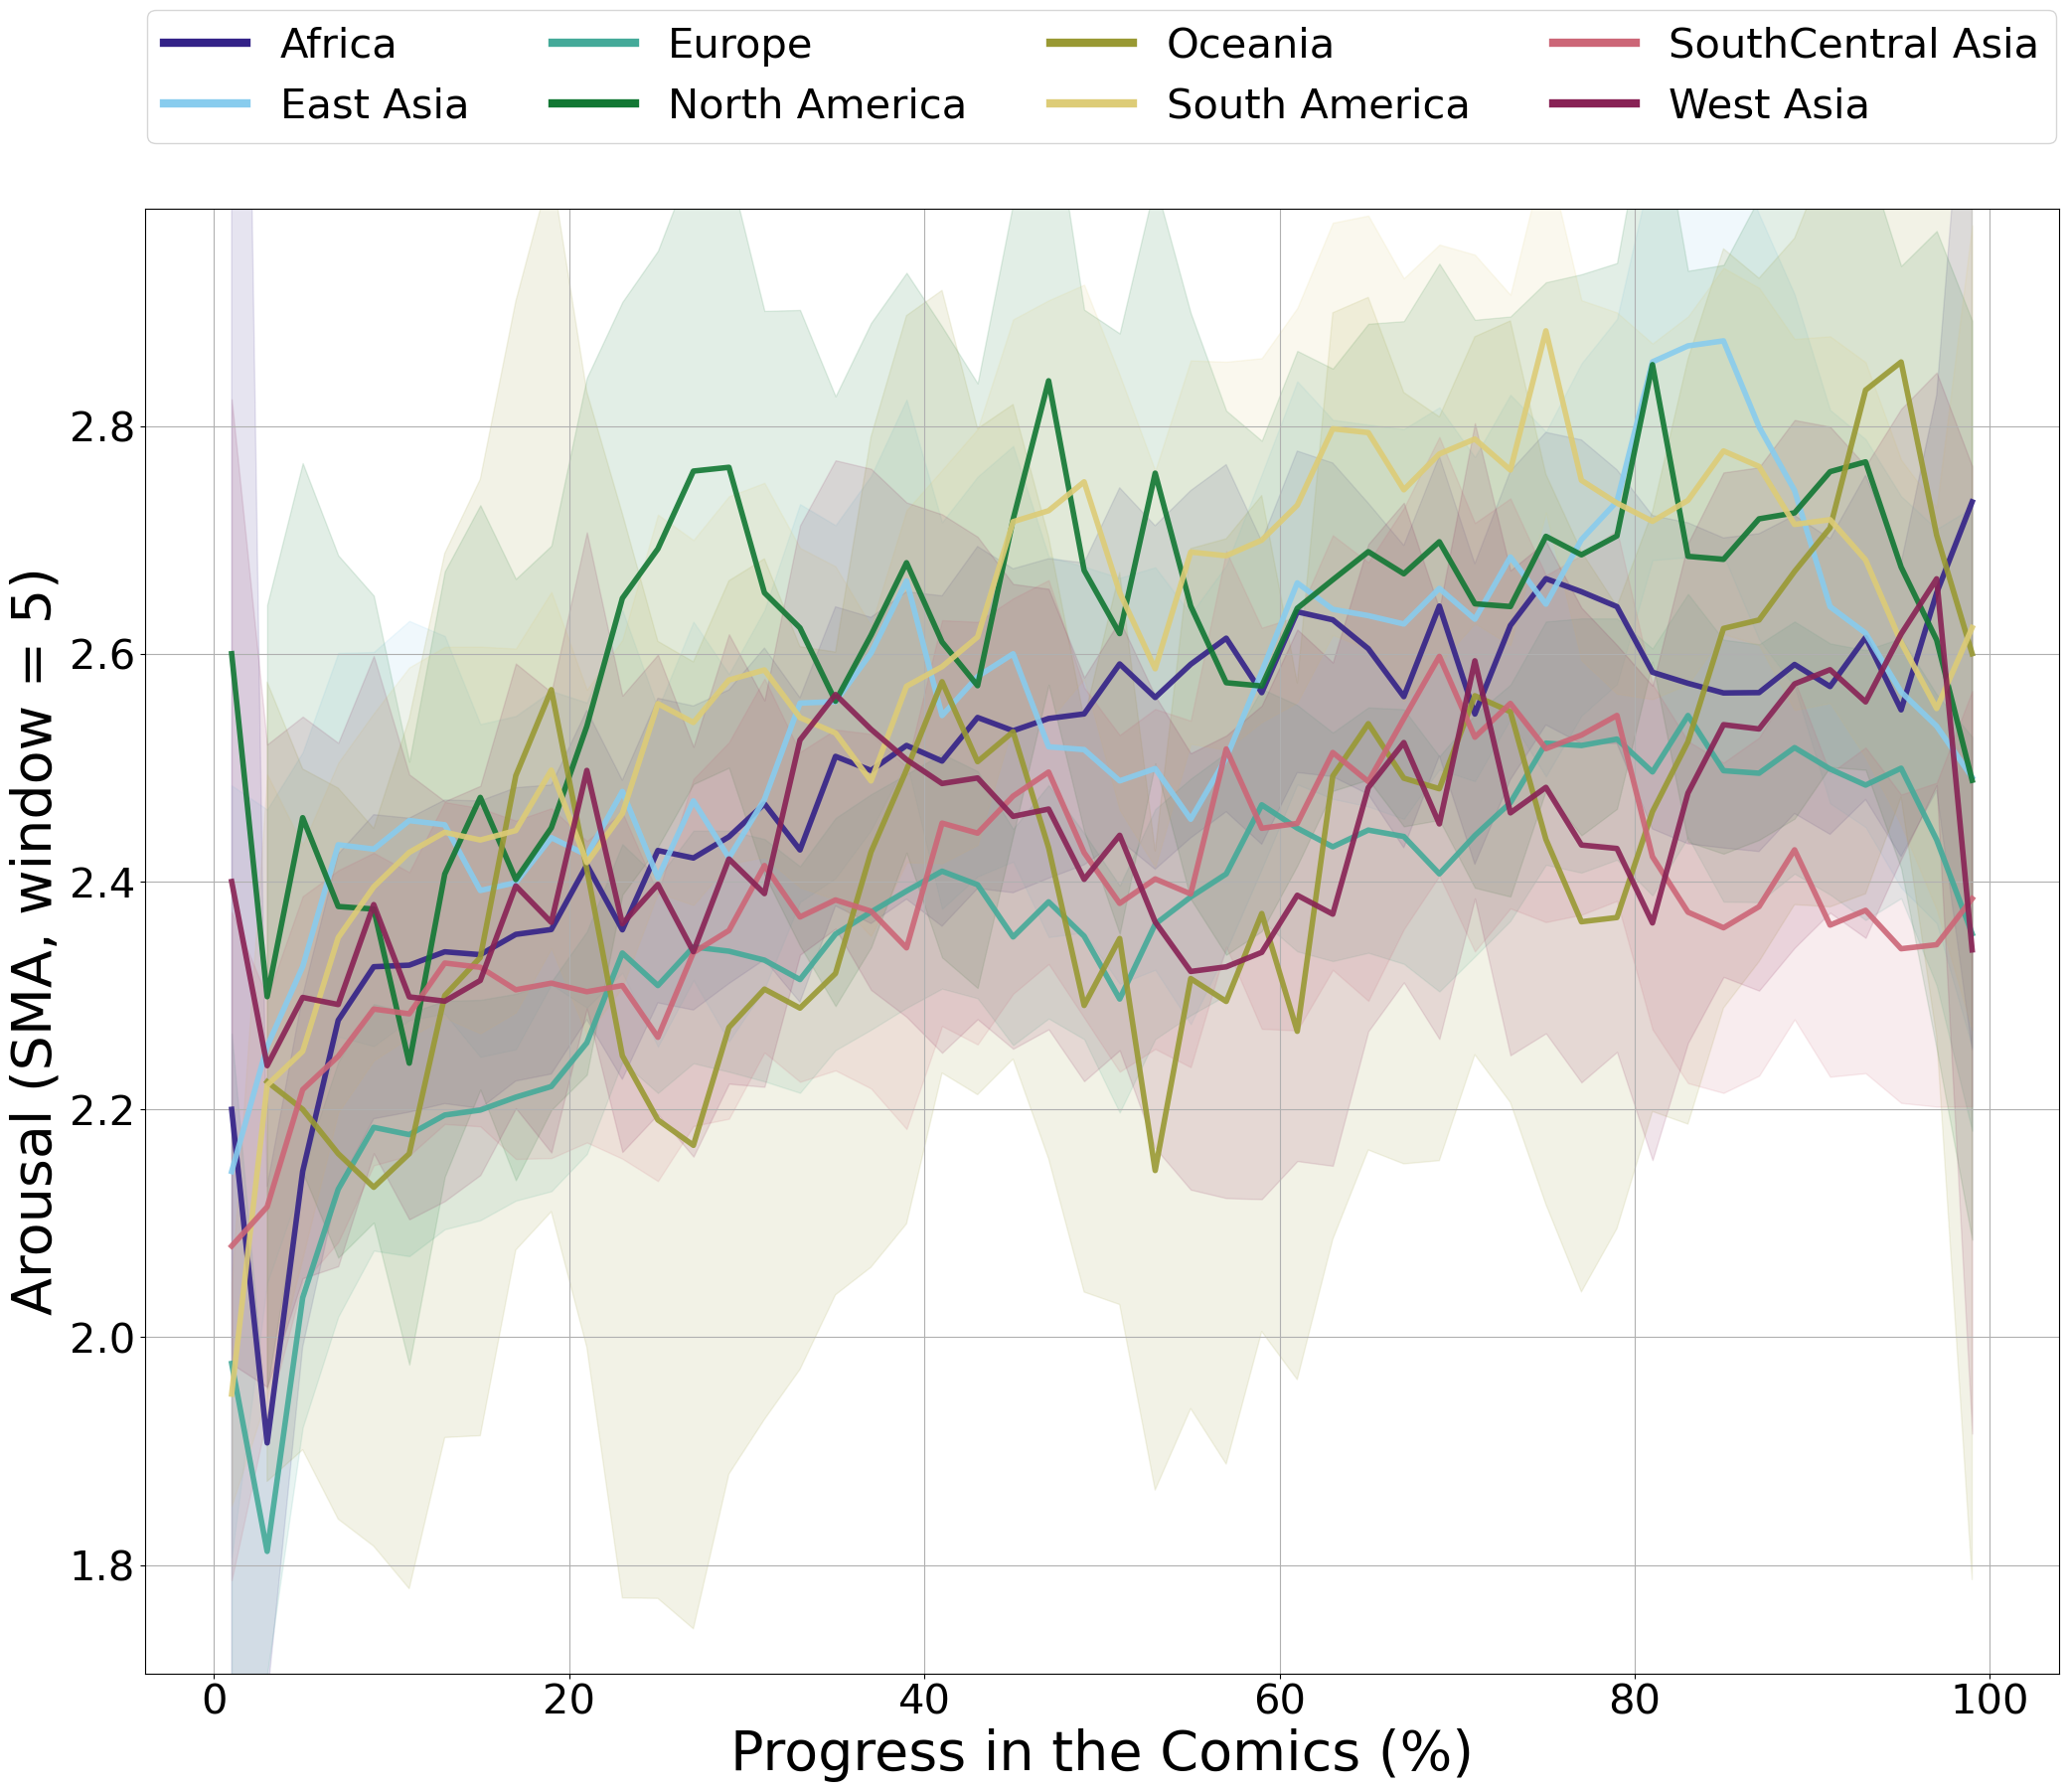

In [21]:
region_names = [
    'Africa',  'East Asia','Europe', 'North America','Oceania', 'South America',"SouthCentral Asia",
    'West Asia',
]

color_palette = [
    "#332288",
    "#88CCEE",
    "#44AA99",
    "#117733",
    "#999933",
    "#DDCC77",
    "#CC6677",
    "#882255",
]

region_colors = dict(zip(region_names, color_palette))

legend_handles = [
    Line2D([0], [0], color=color, lw=6, label=region)
    for region, color in region_colors.items()
]

# Parameters
value_col = 'arousal_roll_5'   
time_col = 'PanelOrdinal'     
n_bins = 50                   

df = df.dropna(subset=[value_col]).copy()

# Step 1: Temporal binning
bins = np.linspace(0, 1, n_bins + 1)

df['progress_bin'] = pd.cut(
    df[time_col],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Step 2: Story × Bin mean
story_bin = (
    df
    .groupby(['RegionSimplified', 'StoryID', 'progress_bin'])[value_col]
    .mean()
    .reset_index()
)

# Step 3: Region × Bin mean + SE (story-weighted)
region_arc = (
    story_bin
    .groupby(['RegionSimplified', 'progress_bin'])[value_col]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

region_arc['SE'] = region_arc['std'] / np.sqrt(region_arc['count'])

# 95% CI 
region_arc['CI'] = 1.96 * region_arc['SE']

# Step 4: Bin centers for x-axis (%)
bin_centers = (bins[:-1] + bins[1:]) / 2 * 100

# Step 5: Plot
fig, ax = plt.subplots(figsize=(22, 18))

for region, color in region_colors.items():

    g = region_arc[region_arc['RegionSimplified'] == region].copy()
    g = g.dropna(subset=['progress_bin'])

    g['progress_bin'] = g['progress_bin'].astype(int)
    g['x'] = bin_centers[g['progress_bin']]

    # Mean arc
    ax.plot(
        g['x'],
        g['mean'],
        color=color,
        linewidth=4,
        alpha=0.9
    )

    # 95% CI band
    ax.fill_between(
        g['x'],
        g['mean'] - g['CI'],
        g['mean'] + g['CI'],
        color=color,
        alpha=0.12
    )

# y-axis padding
ymin = region_arc['mean'].min()
ymax = region_arc['mean'].max()
padding = 0.1 * (ymax - ymin)
ax.set_ylim(ymin - padding, ymax + padding)

ax.set_xlabel('Progress in the Comics (%)', fontsize=40)
ax.set_ylabel('Arousal (SMA, window = 5)', fontsize=40)
ax.grid(True)
ax.tick_params(axis='both', labelsize=30)

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    fontsize=30,
    frameon=True
)

plt.tight_layout()
plt.show()